# Correlated observations

Two datasets that are *individually* independent can still be **coupled** by a
shared systematic — e.g. a common detector calibration, flux normalisation, or
energy scale applied to both. The classic D'Agostini / Barlow point is that
treating such datasets independently is **overconfident**: the shared systematic
cannot average down the way independent errors do.

The covariance API expresses this directly. A `Constraint` owns one multivariate
distribution over the *stacked* vector $y = [y_1; y_2]$, and a covariance `Term`
whose `support` spans **both** blocks writes off-diagonal blocks that couple the
data. This is "case A" of the refactor:

- **case A — coupling the data**: a cross-block `Term` (off-diagonal $\Sigma$).
- **case B — coupling the parameters**: the *same* `Parameter` object shared by two
  block-local terms (one sampled value feeds both; $\Sigma$ stays block-diagonal).

We demonstrate both.

In [1]:
import corner
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

import rxmc

rng = np.random.default_rng(3)

Using database version X4-2024-12-31 located in: /home/kyle/db/exfor/unpack_exfor-2024/X4-2024-12-31


## Two datasets with a shared calibration

A straight-line signal is measured by two instruments over different $x$ ranges.
Both share **one** unknown multiplicative calibration factor $c \sim
\mathcal N(1, \sigma_c)$ drawn once — so both datasets are biased by the *same*
amount. The reported statistical errors are small and independent.

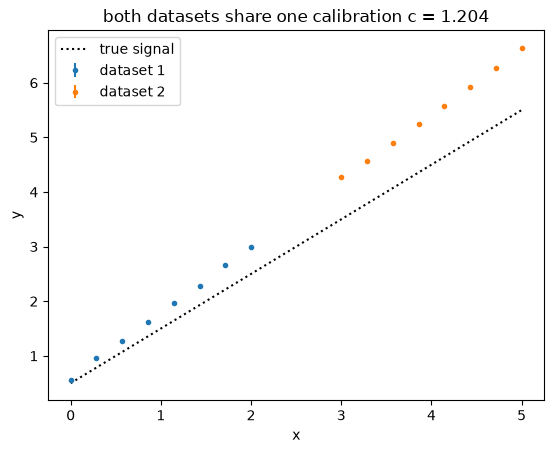

In [2]:
class LinearModel(rxmc.physical_model.PhysicalModel):
    def __init__(self):
        super().__init__(
            [rxmc.params.Parameter("m", float), rxmc.params.Parameter("b", float)]
        )

    def evaluate(self, observation, m, b):
        return self.y(observation.x, m, b)

    def y(self, x, m, b):
        return m * x + b


model = LinearModel()
m_true, b_true = 1.0, 0.5
sigma_c = 0.10  # shared calibration uncertainty
noise = 0.02  # independent statistical error

c = rng.normal(1.0, sigma_c)  # ONE common factor, applied to both datasets
x1 = np.linspace(0.0, 2.0, 8)
x2 = np.linspace(3.0, 5.0, 8)
y1 = c * model.y(x1, m_true, b_true) + rng.normal(0.0, noise, x1.size)
y2 = c * model.y(x2, m_true, b_true) + rng.normal(0.0, noise, x2.size)

obs1 = rxmc.observation.Observation(x=x1, y=y1, y_stat_err=noise * np.ones_like(y1))
obs2 = rxmc.observation.Observation(x=x2, y=y2, y_stat_err=noise * np.ones_like(y2))

xg = np.linspace(0, 5, 100)
plt.plot(xg, model.y(xg, m_true, b_true), "k:", label="true signal")
plt.errorbar(x1, y1, noise, ls="none", marker=".", label="dataset 1")
plt.errorbar(x2, y2, noise, ls="none", marker=".", label="dataset 2")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title(f"both datasets share one calibration c = {c:.3f}");

## The covariance structure

We build the **same** shared-systematic two ways and compare the assembled
$\Sigma$ (via `Constraint.covariance_matrix`):

- **correlated (case A)**: one `normalization_term` over the *full* stacked
  support — its rank-one mode spans both blocks.
- **independent**: a `normalization_term` per dataset (block-local) — no coupling.

correlated  block_diagonal = False
independent block_diagonal = True


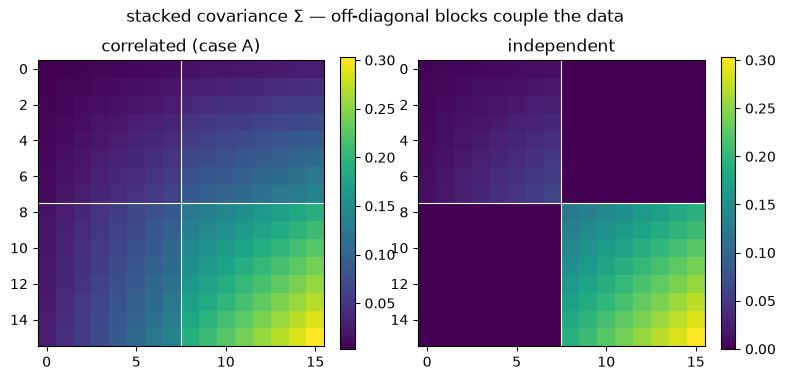

In [3]:
s1, s2 = rxmc.covariance.stacked_supports([obs1, obs2])
full = np.concatenate([s1, s2])
N1 = len(s1)

constraint_corr = rxmc.constraint.Constraint(
    [obs1, obs2],
    model,
    extra_terms=[rxmc.covariance.normalization_term(full, magnitude=sigma_c)],
)
constraint_indep = rxmc.constraint.Constraint(
    [obs1, obs2],
    model,
    extra_terms=[
        rxmc.covariance.normalization_term(s1, magnitude=sigma_c),
        rxmc.covariance.normalization_term(s2, magnitude=sigma_c),
    ],
)

mp = (m_true, b_true)
S_corr = constraint_corr.covariance_matrix(mp)
S_indep = constraint_indep.covariance_matrix(mp)

print("correlated  block_diagonal =", constraint_corr.covariance.block_diagonal)
print("independent block_diagonal =", constraint_indep.covariance.block_diagonal)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, S, t in [
    (axes[0], S_corr, "correlated (case A)"),
    (axes[1], S_indep, "independent"),
]:
    im = ax.imshow(S, cmap="viridis")
    ax.axhline(N1 - 0.5, color="w", lw=0.8)
    ax.axvline(N1 - 0.5, color="w", lw=0.8)
    ax.set_title(t)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(r"stacked covariance $\Sigma$ — off-diagonal blocks couple the data");

The correlated $\Sigma$ has **non-zero off-diagonal blocks** (top-right /
bottom-left): every point in dataset 1 is correlated with every point in dataset 2
through the shared calibration. The independent $\Sigma$ is block-diagonal.

## Effect on inference

Fitting the line under each treatment: the correlated model is appropriately
**less certain** (the shared systematic is a common mode that cannot average
down), while the independent model is **overconfident**.

In [4]:
def fit(constraint, seed):
    evidence = rxmc.evidence.Evidence([constraint])
    prior = stats.multivariate_normal(mean=[1.0, 0.5], cov=np.diag([0.3, 0.3]) ** 2)
    sampler = rxmc.param_sampling.BatchedAdaptiveMetropolisSampler(
        params=model.params,
        starting_location=prior.mean,
        prior=prior,
        initial_proposal_cov=prior.cov / 100,
    )
    walker = rxmc.walker.Walker(sampler, evidence, rng=np.random.default_rng(seed))
    walker.walk(n_steps=6000, burnin=2000, batch_size=1000, verbose=False)
    return walker.model_sampler.chain


chain_corr = fit(constraint_corr, 5)
chain_indep = fit(constraint_indep, 5)

for name, ch in [("correlated", chain_corr), ("independent", chain_indep)]:
    print(
        f"{name:12s}  m = {ch[:,0].mean():.3f} ± {ch[:,0].std():.3f}   "
        f"b = {ch[:,1].mean():.3f} ± {ch[:,1].std():.3f}"
    )

correlated    m = 1.201 ± 0.105   b = 0.582 ± 0.051
independent   m = 1.196 ± 0.079   b = 0.590 ± 0.041


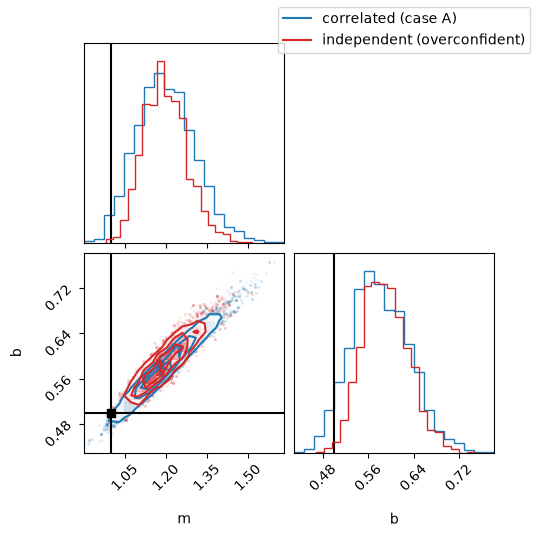

In [5]:
fig = corner.corner(
    chain_corr,
    labels=["m", "b"],
    color="tab:blue",
    truths=[m_true, b_true],
    truth_color="k",
)
corner.corner(chain_indep, fig=fig, color="tab:red")
plt.plot([], [], color="tab:blue", label="correlated (case A)")
plt.plot([], [], color="tab:red", label="independent (overconfident)")
fig.legend(loc="upper right");

## Case A vs case B with a *free* shared nuisance

If the calibration magnitude is itself unknown, it becomes a sampled `Parameter`.
The same `Parameter` object can be wired two ways:

- **case A** — one cross-block term: $\Sigma$ couples the data (off-diagonal).
- **case B** — two block-local terms sharing the *same* `Parameter`: one sampled
  value feeds both, but $\Sigma$ stays **block-diagonal** (the datasets remain
  independent; they only share the uncertainty *magnitude*).

Both have exactly **one** free parameter (gather-by-identity).

In [6]:
eta = rxmc.params.Parameter("log eta", float, latex_name=r"\log{\eta}")

case_A = rxmc.constraint.Constraint(
    [obs1, obs2],
    model,
    extra_terms=[rxmc.covariance.normalization_term(full, parameter=eta)],
)
case_B = rxmc.constraint.Constraint(
    [obs1, obs2],
    model,
    extra_terms=[
        rxmc.covariance.normalization_term(s1, parameter=eta),
        rxmc.covariance.normalization_term(s2, parameter=eta),
    ],
)

for name, c in [("case A (cross-block)", case_A), ("case B (shared param)", case_B)]:
    print(
        f"{name:24s} n_params={c.n_params}  "
        f"block_diagonal={c.covariance.block_diagonal}"
    )

# same single sampled value, different Sigma structure
val = (np.log(sigma_c),)
SA = case_A.covariance_matrix(mp, val)
SB = case_B.covariance_matrix(mp, val)
print("case A cross-block max |Sigma[s1,s2]| =", np.abs(SA[:N1, N1:]).max().round(4))
print("case B cross-block max |Sigma[s1,s2]| =", np.abs(SB[:N1, N1:]).max().round(4))

case A (cross-block)     n_params=1  block_diagonal=False
case B (shared param)    n_params=1  block_diagonal=True
case A cross-block max |Sigma[s1,s2]| = 0.1375
case B cross-block max |Sigma[s1,s2]| = 0.0


## Takeaways

- **Correlated observations are just a covariance `Term` whose `support` spans
  blocks.** No special machinery — a cross-block `normalization_term` (or any
  `RankOneTerm`/`KernelTerm`) writes the off-diagonal $\Sigma$ blocks.
- Treating shared-systematic datasets **independently is overconfident**: the
  common mode cannot average down.
- **A couples the data** (cross-block, off-diagonal $\Sigma$); **B couples the
  parameters** (same `Parameter` shared by block-local terms, $\Sigma$
  block-diagonal). Both are expressed by *where* you put the support and *which*
  `Parameter` object you reuse.

# Shared systematics between cross-section datasets

The toy example above carries over to real reaction data unchanged.  Here two
mock *experiments* measure the same $n + {}^{40}$Ca elastic differential cross
section — one at forward angles, one at backward angles — and both were
normalized against the **same uncertain flux measurement**.  That is case A:
the shared normalization couples the two datasets, so they belong in **one**
`Constraint` with a normalization mode spanning both blocks.


In [7]:
import jitr
from jitr.optical_potentials.potential_forms import (
    thomas_safe,
    woods_saxon_prime_safe,
    woods_saxon_safe,
)

from rxmc.params import Parameter

Ca40 = (40, 20)
neutron = (1, 0)
E_lab = 14.1
rxn = jitr.reactions.ElasticReaction(target=Ca40, projectile=neutron)
mso = 1.0 / jitr.utils.constants.WAVENUMBER_PION


def central_potential(r, Vv, Wv, Rv, av, Wd, Rd, ad):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av) + (
        4j * ad * Wd
    ) * woods_saxon_prime_safe(r, Rd, ad)


def spin_orbit_potential(r, Vso, Wso, Rso, aso):
    return (Vso + 1j * Wso) * mso**2 * thomas_safe(r, Rso, aso)


R40 = 1.2 * 40 ** (1 / 3)
fixed_spin_orbit = (6.0, -3, R40, 0.45)


def extract_params(ws, *x):
    return tuple(x), fixed_spin_orbit


omp = rxmc.elastic_diffxs_model.ElasticDifferentialXSModel(
    "dXS/dA",
    interaction_central=central_potential,
    interaction_spin_orbit=spin_orbit_potential,
    calculate_interaction_from_params=extract_params,
    params=[
        Parameter("Vv", unit="MeV"),
        Parameter("Wv", unit="MeV"),
        Parameter("Rv", unit="fm"),
        Parameter("av", unit="fm"),
        Parameter("Wd", unit="MeV"),
        Parameter("Rd", unit="fm"),
        Parameter("ad", unit="fm"),
    ],
    model_name="shared_flux_demo",
)
omp_true_params = np.array(
    [48.0, 3.5, 1.1 * 40 ** (1 / 3), 0.7, 21, 1.2 * 40 ** (1 / 3), 0.5]
)

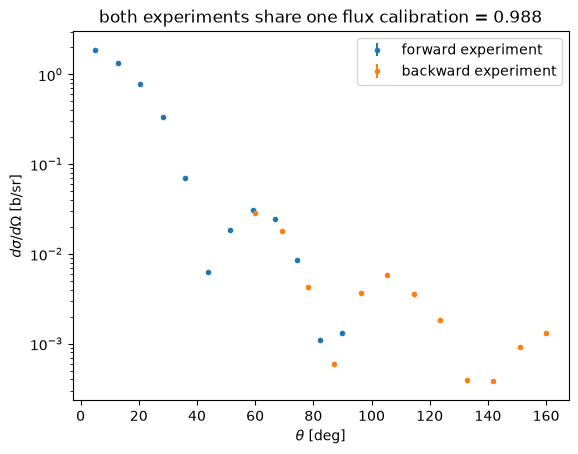

In [8]:
def make_xs_observation(angles_deg, label):
    return rxmc.elastic_diffxs_observation.ElasticDifferentialXSObservation(
        x=angles_deg,
        y=np.ones_like(angles_deg, dtype=float),
        Elab=E_lab,
        reaction=rxn,
        quantity="dXS/dA",
        measurement_quantity="dXS/dA",
        y_units="barn / steradian",
        dataset_label=label,
    )


sigma_flux = 0.05  # one flux calibration, shared by both experiments
flux = rng.normal(1.0, sigma_flux)

angles_fwd = np.linspace(5.0, 90.0, 12)
angles_bwd = np.linspace(60.0, 160.0, 12)

obs_fwd = make_xs_observation(angles_fwd, "forward experiment")
obs_bwd = make_xs_observation(angles_bwd, "backward experiment")

for o in (obs_fwd, obs_bwd):
    y_true = omp.evaluate(o, *omp_true_params)
    stat = 0.05 * np.maximum(y_true, 1e-4)
    o.y = np.clip(flux * y_true + rng.normal(scale=stat), 1e-6, None)
    o.y_stat_err = stat

for o in (obs_fwd, obs_bwd):
    plt.errorbar(
        np.rad2deg(o.x), o.y, o.y_stat_err, ls="none", marker=".", label=o.subentry
    )
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$d\sigma/d\Omega$ [b/sr]")
plt.yscale("log")
plt.legend()
plt.title(f"both experiments share one flux calibration = {flux:.3f}");

## One constraint, one cross-block normalization mode

Exactly as in the toy: the coupled covariance gets a single
`normalization_term` whose support spans **both** blocks; the independent
alternative gives each experiment its own block-local mode.


coupled block-diagonal? False
independent block-diagonal? True


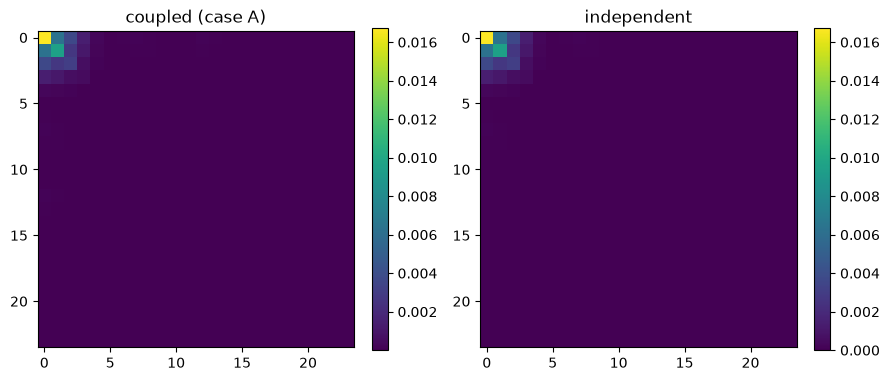

In [9]:
s_fwd, s_bwd = rxmc.covariance.stacked_supports([obs_fwd, obs_bwd])
s_all = np.concatenate([s_fwd, s_bwd])

xs_coupled = rxmc.constraint.Constraint(
    [obs_fwd, obs_bwd],
    omp,
    extra_terms=[rxmc.covariance.normalization_term(s_all, magnitude=sigma_flux)],
)
xs_indep = rxmc.constraint.Constraint(
    [obs_fwd, obs_bwd],
    omp,
    extra_terms=[
        rxmc.covariance.normalization_term(s_fwd, magnitude=sigma_flux),
        rxmc.covariance.normalization_term(s_bwd, magnitude=sigma_flux),
    ],
)
print("coupled block-diagonal?", xs_coupled.covariance.block_diagonal)
print("independent block-diagonal?", xs_indep.covariance.block_diagonal)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for a, (c, title) in zip(
    axes,
    [(xs_coupled, "coupled (case A)"), (xs_indep, "independent")],
):
    im = a.imshow(c.covariance_matrix(omp_true_params), cmap="viridis")
    a.set_title(title)
    fig.colorbar(im, ax=a, fraction=0.046)
fig.tight_layout()

In [10]:
%%time
xs_prior = stats.multivariate_normal(
    mean=np.array([50.0, 3, 1.2 * 40 ** (1 / 3), 0.65, 18, 1.2 * 40 ** (1 / 3), 0.65]),
    cov=np.diag([7, 7, 0.2, 0.2, 10, 0.2, 0.2]) ** 2,
)


def fit_xs(constraint, seed):
    walker = rxmc.walker.Walker(
        rxmc.param_sampling.BatchedAdaptiveMetropolisSampler(
            params=omp.params,
            starting_location=xs_prior.mean,
            prior=xs_prior,
            initial_proposal_cov=xs_prior.cov / 100,
        ),
        rxmc.evidence.Evidence([constraint]),
        rng=np.random.default_rng(seed),
    )
    walker.walk(n_steps=6000, burnin=1500, batch_size=1000, verbose=False)
    return walker.model_sampler.chain


xs_chain_coupled = fit_xs(xs_coupled, 8)
xs_chain_indep = fit_xs(xs_indep, 8)

CPU times: user 45.8 s, sys: 2.09 ms, total: 45.8 s
Wall time: 45.7 s


coupled       Vv=45.63±2.31  Wv=4.19±0.82  Rv=3.90±0.14  av=0.67±0.02  Wd=20.38±1.44  Rd=4.09±0.03  ad=0.50±0.02
independent   Vv=46.78±1.82  Wv=4.16±0.87  Rv=3.84±0.11  av=0.68±0.02  Wd=20.40±1.40  Rd=4.11±0.03  ad=0.50±0.02


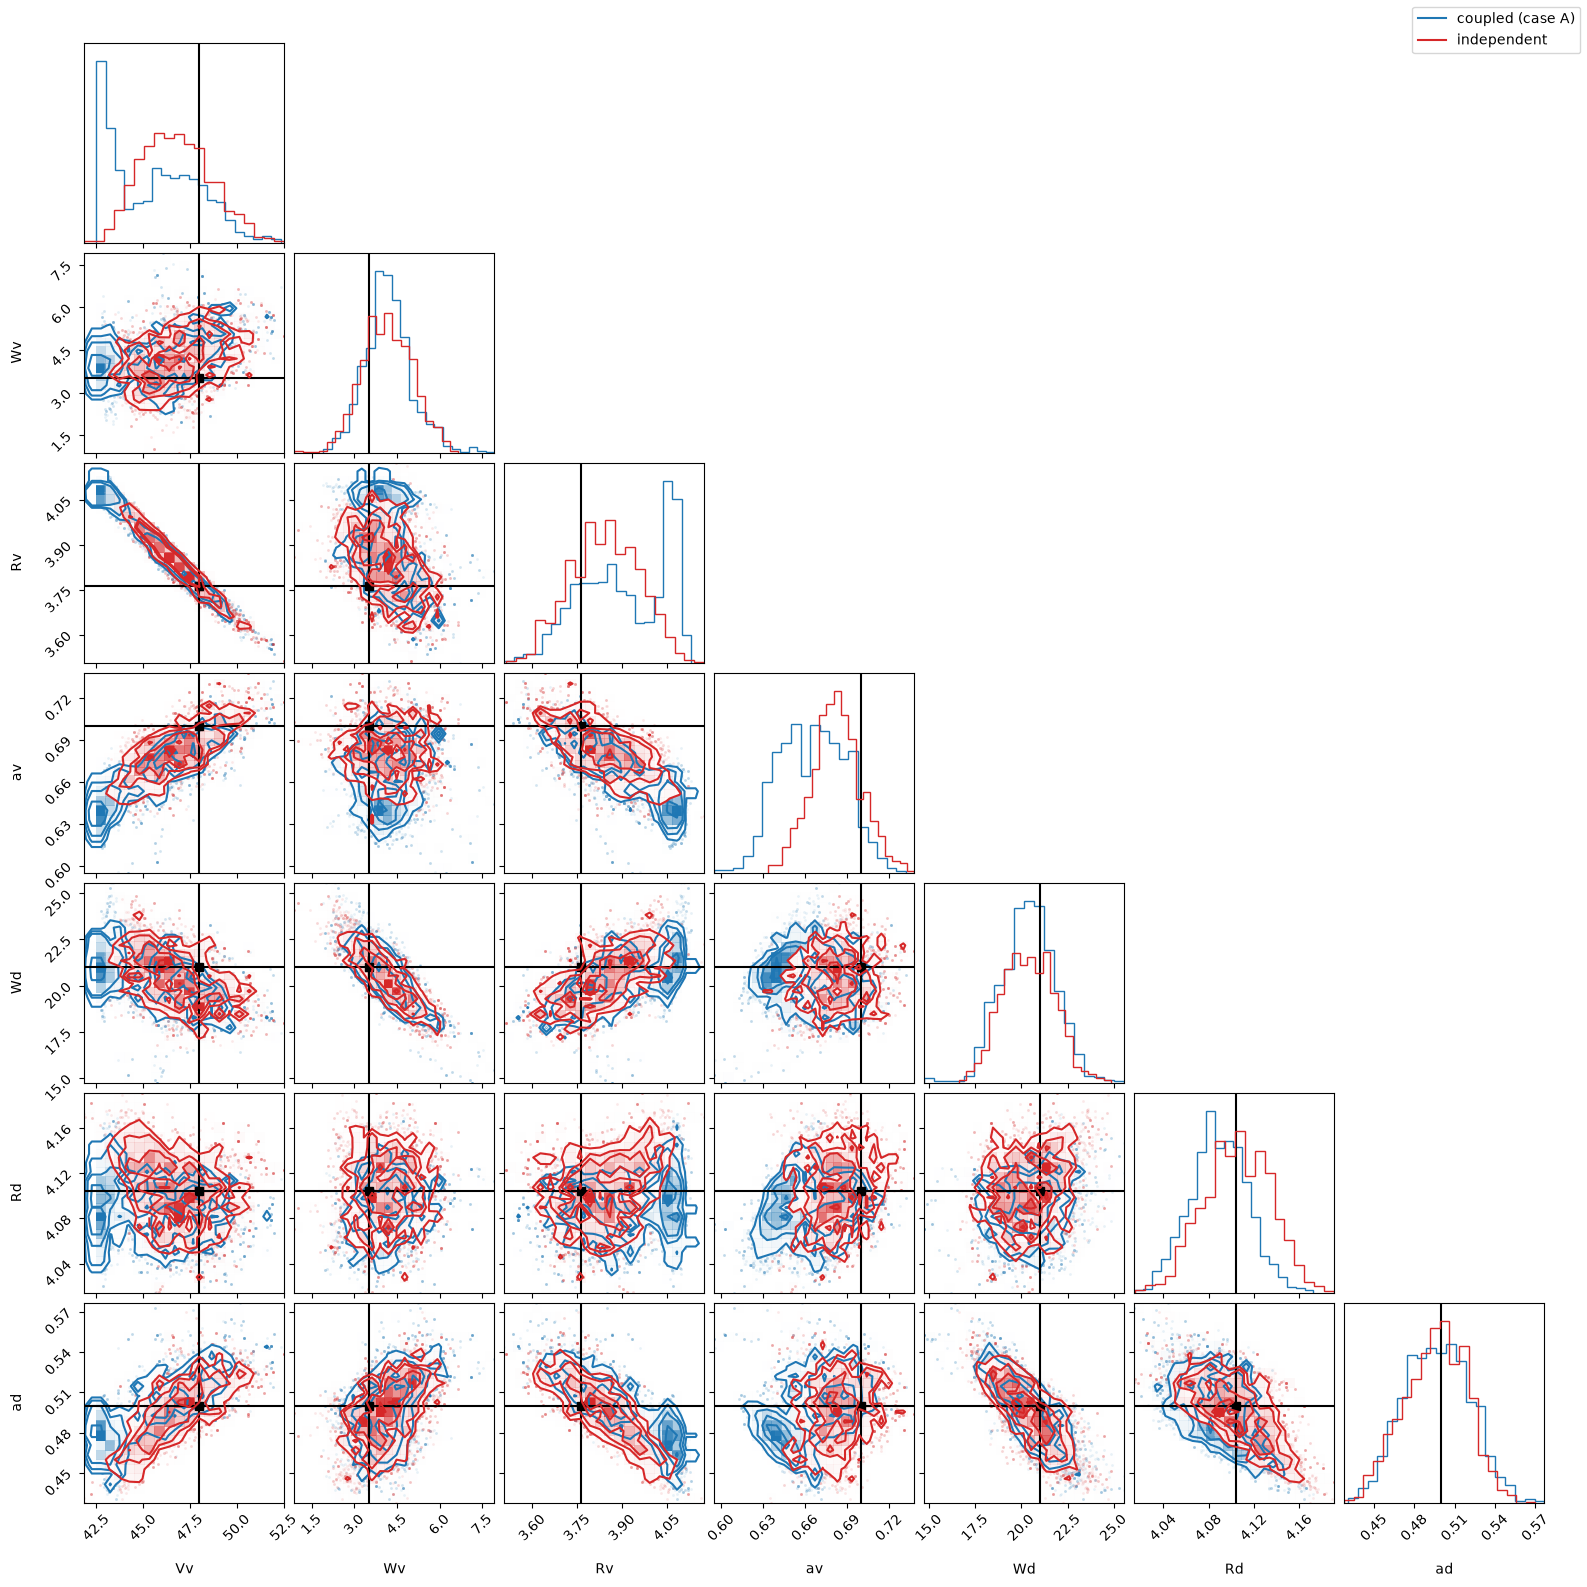

In [11]:
for name, ch in [("coupled", xs_chain_coupled), ("independent", xs_chain_indep)]:
    print(
        f"{name:12s}  "
        + "  ".join(
            f"{p.name}={ch[:, i].mean():.2f}±{ch[:, i].std():.2f}"
            for i, p in enumerate(omp.params)
        )
    )

fig = corner.corner(
    xs_chain_coupled,
    labels=[p.name for p in omp.params],
    truths=omp_true_params,
    truth_color="k",
    color="tab:blue",
)
corner.corner(xs_chain_indep, fig=fig, color="tab:red")
plt.plot([], [], color="tab:blue", label="coupled (case A)")
plt.plot([], [], color="tab:red", label="independent")
fig.legend(loc="upper right");

## Takeaways, continued

- **Real reaction data changes nothing structurally**: the shared-flux coupling
  is the same three lines as the toy — put both experiments in one `Constraint`
  and give the `normalization_term` a support spanning both blocks.
- The independent spelling silently claims the two flux calibrations could
  fluctuate separately — a stronger (and here wrong) assumption, visible as the
  covariance heatmap's missing off-diagonal blocks.
